# Análisis de la mejor división temporal

En este notebook analizaremos cual es la mejor división temporal, usando como datos el parquet de datos de enero que se puede extraer con la API de descarga de este mismo proyecto.

Librerías necesarias

In [2]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import numpy as np


Importamos los datos de minio, solo ejecutar si no has descargado los datos en local

In [ ]:
import sys
from pathlib import Path

root = Path.cwd().parent / "minio_utils"
sys.path.append(str(root))

from minio_script import MinioPD2

path = Path.cwd()
if not Path(path, "data").exists(): path = path.parent
path_data = path / "data" / "january.parquet"
minio = MinioPD2()
minio.download_file(path / "data", file_name=path_data.name)

Descargamos los datos

In [4]:
lz = pl.scan_parquet(path_data)

Y creamos una función para separar por franja temporal

In [5]:

def prepare_tft_dataset(lf: pl.LazyFrame, time_split: str = "30m") -> pl.DataFrame:
    final_df = (
        lf.with_columns([
            pl.col("pickup_datetime").dt.truncate(time_split).alias("pickup_interval")
        ])
        .group_by(["VendorID", "PULocationID", "pickup_interval"])
        .agg([
            pl.len().alias("demanda"),
            pl.col("total_amount").mean().alias("precio_medio"),
            pl.col("total_amount").std().alias("precio_std"),
            pl.col("trip_distance").mean().alias("distancia_media")
        ])
        .collect()
    )

    # 2. Upsampling (Rellenar huecos)
    final_df = (
        final_df.sort("pickup_interval")
        .upsample(
            time_column="pickup_interval",
            every=time_split,
            group_by=["VendorID", "PULocationID"]
        )
        .with_columns([
            pl.col("demanda").fill_null(0).cast(pl.Float32), # Float32 ahorra RAM
            pl.col("precio_medio").fill_null(0).cast(pl.Float32),
            pl.col("precio_std").fill_null(0).cast(pl.Float32),
            pl.col("distancia_media").fill_null(0).cast(pl.Float32)
        ])
    )

    # 3. Transformación Cíclica y limpieza de Invariantes
    min_date = final_df["pickup_interval"].min()
    
    final_df = final_df.with_columns([
        # time_idx como entero (mínimo espacio)
        ((pl.col("pickup_interval") - min_date).dt.total_seconds() / 1800)
        .cast(pl.Int32)
        .alias("time_idx"),

        # Dejamos VendorID y PULocationID como String porque son 
        # las únicas categorías reales que el modelo necesita identificar
        pl.col("VendorID").cast(pl.String),
        pl.col("PULocationID").cast(pl.String),
        
        # --- HORA CÍCLICA ---
        # Representamos la hora como un círculo para que las 23:30 esté cerca de las 00:00
        (pl.col("pickup_interval").dt.hour() + (pl.col("pickup_interval").dt.minute() / 60.0)).alias("_tmp_hour")
    ]).with_columns([
        (pl.col("_tmp_hour") * (2 * np.pi / 24)).sin().cast(pl.Float32).alias("hour_sin"),
        (pl.col("_tmp_hour") * (2 * np.pi / 24)).cos().cast(pl.Float32).alias("hour_cos"),
        
        # --- DÍA CÍCLICO ---
        (pl.col("pickup_interval").dt.weekday() * (2 * np.pi / 7)).sin().cast(pl.Float32).alias("day_sin"),
        (pl.col("pickup_interval").dt.weekday() * (2 * np.pi / 7)).cos().cast(pl.Float32).alias("day_cos")
    ]).drop(["_tmp_hour"]) # Limpiamos columnas temporales

    return final_df

## Idea 1, división cada media hora:

El batch habitual es cada media hora, probemos a ver si la demanda tiene una distribución que no parezca aleatoria o constante

In [6]:
#creamos agregaciones cada 30 minutos
df_30 = prepare_tft_dataset(lz, time_split="30m").to_pandas()
df_30

,VendorID,PULocationID,pickup_interval,demanda,precio_medio,precio_std,distancia_media,time_idx,hour_sin,hour_cos,day_sin,day_cos
0,3,27,2025-01-01 01:30:00,2.0,112.800003,9.842926,27.035000,293,0.382683,0.923880,0.433884,-0.900969
1,3,27,2025-01-01 02:00:00,0.0,0.000000,0.000000,0.000000,294,0.500000,0.866025,0.433884,-0.900969
2,3,27,2025-01-01 02:30:00,0.0,0.000000,0.000000,0.000000,295,0.608761,0.793353,0.433884,-0.900969
3,3,27,2025-01-01 03:00:00,0.0,0.000000,0.000000,0.000000,296,0.707107,0.707107,0.433884,-0.900969
4,3,27,2025-01-01 03:30:00,1.0,12.770000,0.000000,1.334000,297,0.793353,0.608761,0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...
1372006,1,116,2025-01-31 21:30:00,4.0,18.500000,160.556656,20.822500,1773,-0.608761,0.793353,-0.974928,-0.222521
1372007,1,116,2025-01-31 22:00:00,6.0,15.498333,4.371437,2.496667,1774,-0.500000,0.866025,-0.974928,-0.222521
1372008,1,116,2025-01-31 22:30:00,10.0,20.721001,11.896443,4.085000,1775,-0.382683,0.923880,-0.974928,-0.222521
1372009,1,116,2025-01-31 23:00:00,5.0,20.556000,8.026978,3.624000,1776,-0.258819,0.965926,-0.974928,-0.222521


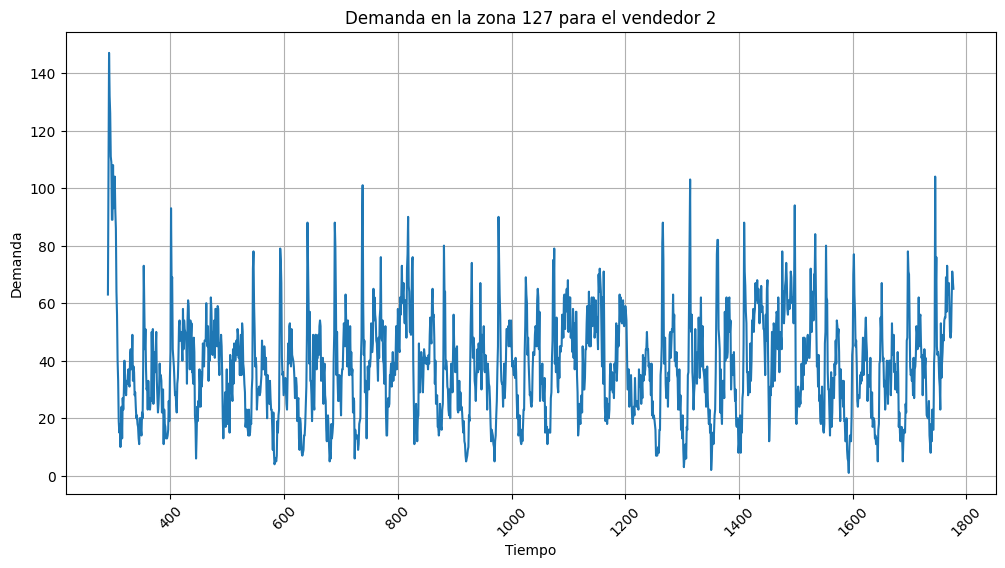

In [7]:
#mostremos la distribución de la zona 127 en el vendedor 2

df_127 = df_30[df_30["PULocationID"] == "127"]
df_127_v2 = df_127[df_127["VendorID"] == "2"]
plt.figure(figsize=(12,6))
plt.plot(df_127_v2["time_idx"], df_127_v2["demanda"])
plt.title("Demanda en la zona 127 para el vendedor 2")
plt.xlabel("Tiempo")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Vemos que hay muchos puntos, lo que puede implicar un exceso de datos además de pocos puntos intermedios, lo que dificultaría el entrenamiento

## Idea 2, división cada hora hora:

Viendo que cada media es muy aleatorio, aumentaremos la franja temporal con el fin de suavizar los picos

In [43]:
df_1h = prepare_tft_dataset(lz, time_split="1h").to_pandas()
df_1h

,VendorID,PULocationID,pickup_interval,demanda,precio_medio,precio_std,distancia_media,time_idx,hour_sin,hour_cos,day_sin,day_cos
0,3,96,2025-01-01 01:00:00,1.0,43.970001,0.000000,5.789000,292,0.258819,0.965926,0.433884,-0.900969
1,3,96,2025-01-01 02:00:00,1.0,28.290001,0.000000,2.088000,294,0.500000,0.866025,0.433884,-0.900969
2,3,96,2025-01-01 03:00:00,1.0,12.680000,0.000000,0.651000,296,0.707107,0.707107,0.433884,-0.900969
3,3,96,2025-01-01 04:00:00,2.0,26.365000,3.471894,5.731500,298,0.866025,0.500000,0.433884,-0.900969
4,3,96,2025-01-01 05:00:00,0.0,0.000000,0.000000,0.000000,300,0.965926,0.258819,0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...
686207,2,195,2025-01-31 19:00:00,53.0,34.988678,23.254213,6.365283,1768,-0.965926,0.258819,-0.974928,-0.222521
686208,2,195,2025-01-31 20:00:00,56.0,27.632500,13.434988,5.474286,1770,-0.866025,0.500000,-0.974928,-0.222521
686209,2,195,2025-01-31 21:00:00,53.0,25.589245,13.058760,5.143396,1772,-0.707107,0.707107,-0.974928,-0.222521
686210,2,195,2025-01-31 22:00:00,49.0,24.001633,13.739563,4.708571,1774,-0.500000,0.866025,-0.974928,-0.222521


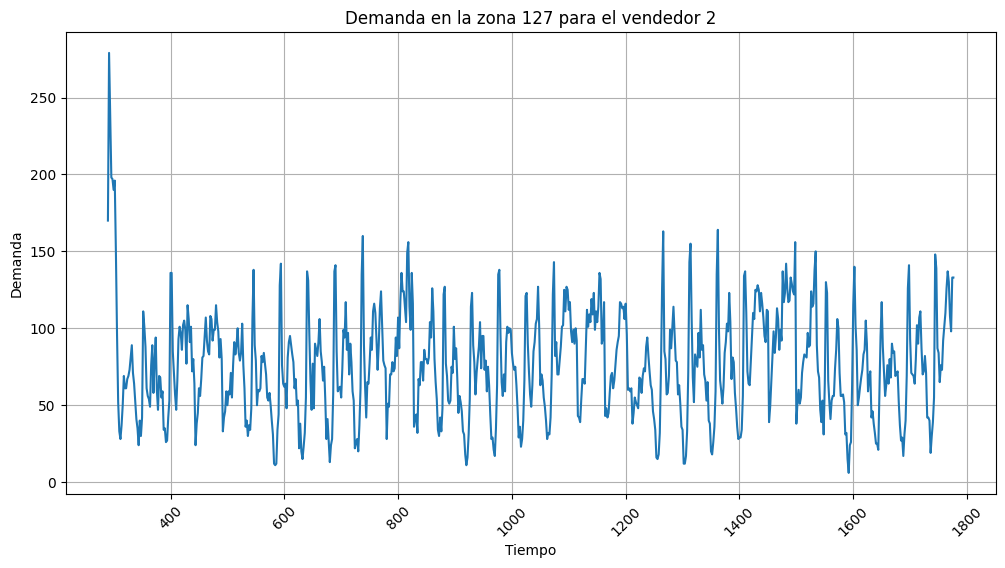

In [45]:
#mostremos la distribución de la zona 127 en el vendedor 2

df_127 = df_1h[df_1h["PULocationID"] == "127"]
df_127_v2 = df_127[df_127["VendorID"] == "2"]
plt.figure(figsize=(12,6))
plt.plot(df_127_v2["time_idx"], df_127_v2["demanda"])
plt.title("Demanda en la zona 127 para el vendedor 2")
plt.xlabel("Tiempo")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Vemos que con una hora hay menos picos y puntos intermedios, estos puntos son clave para que el modelo se pueda entrenar bien.

## Idea 3: División cada 2 horas

Puede ser una división muy agresiva pero vamos a probarla ya que en caso de ser suficientemente buena disminuye mucho la cantidad de filas, optimizando el entrenamiento.

In [46]:
df_2h = prepare_tft_dataset(lz, time_split="2h").to_pandas()
df_2h

,VendorID,PULocationID,pickup_interval,demanda,precio_medio,precio_std,distancia_media,time_idx,hour_sin,hour_cos,day_sin,day_cos
0,1,37,2025-01-01 00:00:00,30.0,34.494999,19.842188,5.768000,292,0.000000,1.000000e+00,0.433884,-0.900969
1,1,37,2025-01-01 02:00:00,89.0,18.920338,20.247812,6.119888,296,0.500000,8.660254e-01,0.433884,-0.900969
2,1,37,2025-01-01 04:00:00,64.0,15.158125,18.926737,5.372812,300,0.866025,5.000000e-01,0.433884,-0.900969
3,1,37,2025-01-01 06:00:00,24.0,9.212083,13.631491,4.147500,304,1.000000,6.123234e-17,0.433884,-0.900969
4,1,37,2025-01-01 08:00:00,9.0,6.480000,11.910669,5.148889,308,0.866025,-5.000000e-01,0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...
343290,1,186,2025-01-31 14:00:00,435.0,21.846989,14.754552,2.065816,1760,-0.500000,-8.660254e-01,-0.974928,-0.222521
343291,1,186,2025-01-31 16:00:00,626.0,23.877859,16.081463,1.917093,1764,-0.866025,-5.000000e-01,-0.974928,-0.222521
343292,1,186,2025-01-31 18:00:00,733.0,23.202032,13.107373,1.773997,1768,-1.000000,-1.836970e-16,-0.974928,-0.222521
343293,1,186,2025-01-31 20:00:00,319.0,24.922413,12.937981,2.358150,1772,-0.866025,5.000000e-01,-0.974928,-0.222521


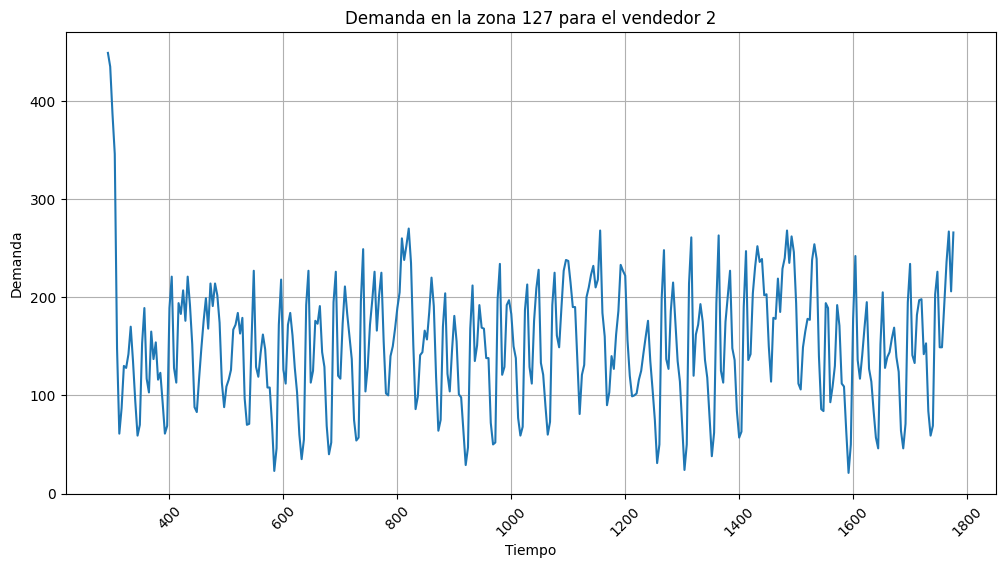

In [47]:
#mostremos la distribución de la zona 127 en el vendedor 2

df_127 = df_2h[df_2h["PULocationID"] == "127"]
df_127_v2 = df_127[df_127["VendorID"] == "2"]
plt.figure(figsize=(12,6))
plt.plot(df_127_v2["time_idx"], df_127_v2["demanda"])
plt.title("Demanda en la zona 127 para el vendedor 2")
plt.xlabel("Tiempo")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Volvemos a perder los puntos intermedio y ha pasar de un pico alto a uno bajo, lo que implica que descartamos la idea

## Idea 4: 45 minutos

Como última prueba probemos 45 minutos al ser un punto intermedio de las dos primeras

In [48]:
df_45 = prepare_tft_dataset(lz, time_split="45m").to_pandas()
df_45

,VendorID,PULocationID,pickup_interval,demanda,precio_medio,precio_std,distancia_media,time_idx,hour_sin,hour_cos,day_sin,day_cos
0,2,36,2025-01-01 00:00:00,521.0,25.881516,19.565983,4.373282,291,0.000000,1.000000,0.433884,-0.900969
1,2,36,2025-01-01 00:45:00,616.0,48.456738,24.143448,4.440503,292,0.195090,0.980785,0.433884,-0.900969
2,2,36,2025-01-01 01:30:00,647.0,52.109459,24.946596,5.008223,294,0.382683,0.923880,0.433884,-0.900969
3,2,36,2025-01-01 02:15:00,750.0,49.761932,23.903112,5.295187,295,0.555570,0.831470,0.433884,-0.900969
4,2,36,2025-01-01 03:00:00,733.0,41.882416,24.531168,5.059345,297,0.707107,0.707107,0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...
914802,3,161,2025-01-31 20:15:00,87.0,36.706551,33.631042,5.317839,1771,-0.831470,0.555570,-0.974928,-0.222521
914803,3,161,2025-01-31 21:00:00,86.0,32.855930,15.699223,4.669977,1773,-0.707107,0.707107,-0.974928,-0.222521
914804,3,161,2025-01-31 21:45:00,90.0,40.995556,33.196041,6.892689,1774,-0.555570,0.831470,-0.974928,-0.222521
914805,3,161,2025-01-31 22:30:00,91.0,38.216812,25.486500,5.974627,1776,-0.382683,0.923880,-0.974928,-0.222521


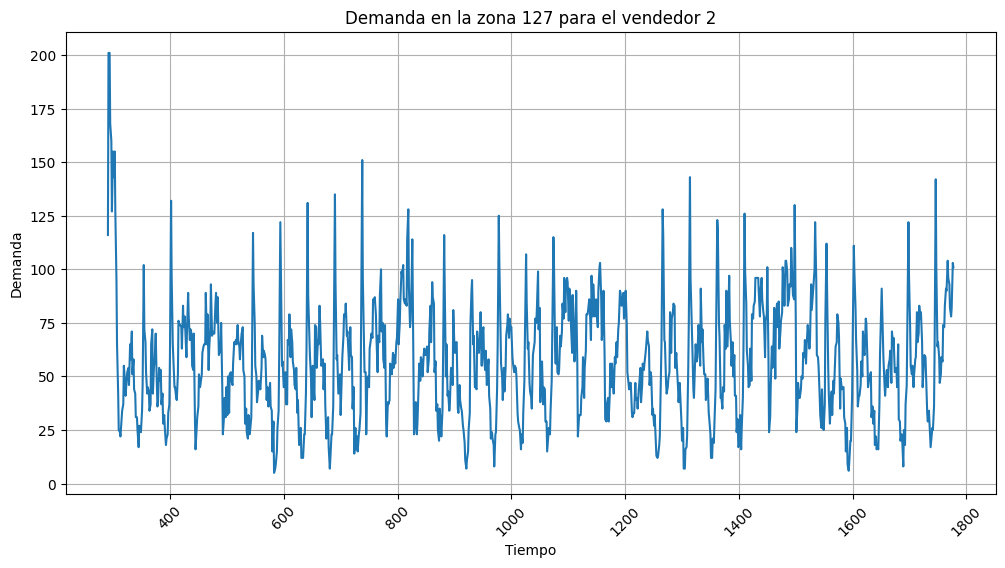

In [49]:
#mostremos la distribución de la zona 127 en el vendedor 2

df_127 = df_45[df_45["PULocationID"] == "127"]
df_127_v2 = df_127[df_127["VendorID"] == "2"]
plt.figure(figsize=(12,6))
plt.plot(df_127_v2["time_idx"], df_127_v2["demanda"])
plt.title("Demanda en la zona 127 para el vendedor 2")
plt.xlabel("Tiempo")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.grid()
plt.show()

También optenemos una buena distribución con muchos puntos intermedios.

Viendo las 4 pruebas, la división de 1 hora o 45 minutos, en función de la cantidad de datos que tengamos serían las mejores opciones